In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('/content/StudentPerformanceFactors.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
df.shape

(6607, 20)

In [6]:
df.sample(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
673,18,76,High,High,No,6,79,Medium,Yes,1,Medium,Medium,Private,Positive,2,No,Postgraduate,Far,Female,67
4372,13,77,High,High,No,7,58,Medium,Yes,2,Low,Medium,Public,Positive,3,No,High School,Near,Male,66
6244,16,84,Medium,High,Yes,6,93,Medium,Yes,0,High,Medium,Public,Positive,3,No,High School,Moderate,Male,69
5759,25,66,Medium,High,Yes,7,91,Medium,Yes,2,Low,High,Public,Neutral,3,No,College,Near,Male,68
877,21,71,Medium,Low,No,8,86,Medium,Yes,2,Medium,High,Public,Neutral,2,No,College,Near,Male,66


In [7]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [9]:
values_teachQuality = df['Teacher_Quality'].unique()
values_parentEducationLevel = df['Parental_Education_Level'].unique()
values_distanceFromHome = df['Distance_from_Home'].unique()
print(values_teachQuality)
print(values_parentEducationLevel)
print(values_distanceFromHome)

['Medium' 'High' 'Low' nan]
['High School' 'College' 'Postgraduate' nan]
['Near' 'Moderate' 'Far' nan]


In [10]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna('Unknown')
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna('Unknown')
df['Distance_from_Home'] = df['Distance_from_Home'].fillna('Unknown')

In [11]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [12]:
motivation_map = {'Unknown':0, 'Low':1, 'Medium':2, 'High':3}
teacher_map = {'Unknown':0, 'Low':1, 'Medium':2, 'High':3}
parent_map = {'Unknown':0, 'High School':1, 'College':2, 'Postgraduate':3}
distance_map = {'Unknown':0, 'Far':1, 'Moderate':2, 'Near':3}

df['Teacher_Quality_num'] = df['Teacher_Quality'].map(teacher_map)
df['Parental_Education_num'] = df['Parental_Education_Level'].map(parent_map)
df['Distance_num'] = df['Distance_from_Home'].map(distance_map)
df['Motivation_Level'] = df['Motivation_Level'].map(motivation_map)

In [13]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Physical_Activity,Exam_Score,Teacher_Quality_num,Parental_Education_num,Distance_num
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.906463,1.493719,2.967610,67.235659,2.171636,1.682458,2.467988
std,5.990594,11.547475,1.46812,14.399784,0.695798,1.230570,1.031231,3.890456,0.641836,0.799428,0.713498
min,1.000000,60.000000,4.00000,50.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,1.000000,2.000000,65.000000,2.000000,1.000000,2.000000
50%,20.000000,80.000000,7.00000,75.000000,2.000000,1.000000,3.000000,67.000000,2.000000,1.000000,3.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,2.000000,4.000000,69.000000,3.000000,2.000000,3.000000
max,44.000000,100.000000,10.00000,100.000000,3.000000,8.000000,6.000000,101.000000,3.000000,3.000000,3.000000


##Correlation

In [14]:
df.corr(numeric_only=True)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Physical_Activity,Exam_Score,Teacher_Quality_num,Parental_Education_num,Distance_num
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.010396,-0.014282,0.004624,0.445455,-0.002363,-0.010898,-0.006117
Attendance,-0.009908,1.000000,-0.015918,-0.020186,-0.005010,0.014324,-0.022435,0.581072,0.005404,0.024756,0.025185
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,0.001031,-0.012216,-0.000378,-0.017022,0.007397,0.010314,0.008114
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,0.006460,-0.013122,-0.011274,0.175079,-0.006338,-0.009153,0.006275
Motivation_Level,-0.010396,-0.005010,0.001031,0.006460,1.000000,0.001258,-0.007388,0.086937,-0.007772,-0.003331,-0.002373
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,0.001258,1.000000,0.017733,0.156525,0.001557,0.006435,0.018176
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,-0.007388,0.017733,1.000000,0.027824,-0.011040,-0.026800,0.015461
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.086937,0.156525,0.027824,1.000000,0.076916,0.101940,0.092345
Teacher_Quality_num,-0.002363,0.005404,0.007397,-0.006338,-0.007772,0.001557,-0.011040,0.076916,1.000000,0.000322,0.010347
Parental_Education_num,-0.010898,0.024756,0.010314,-0.009153,-0.003331,0.006435,-0.026800,0.101940,0.000322,1.000000,-0.008535


In [15]:
numeric_df = df.select_dtypes(include=['int64'])

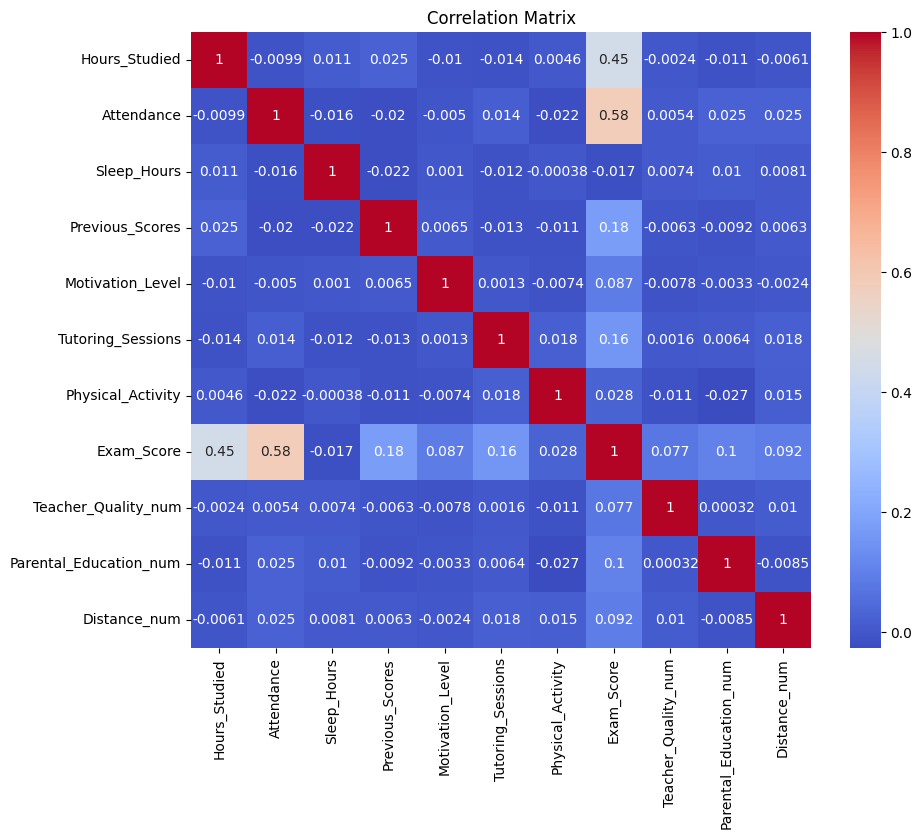

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

##Gender Distribution

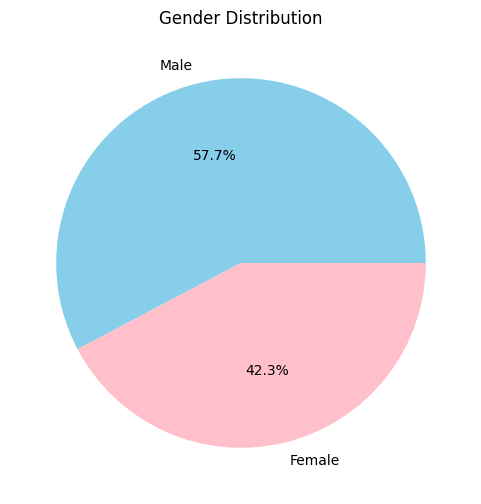

In [17]:
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','pink'],
    figsize=(6,6)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

#1. Вопрос: как Hours_Studied влияет на Exam_Score?

###1. Взаимосвязь между Hours_Studied и Exam_Score

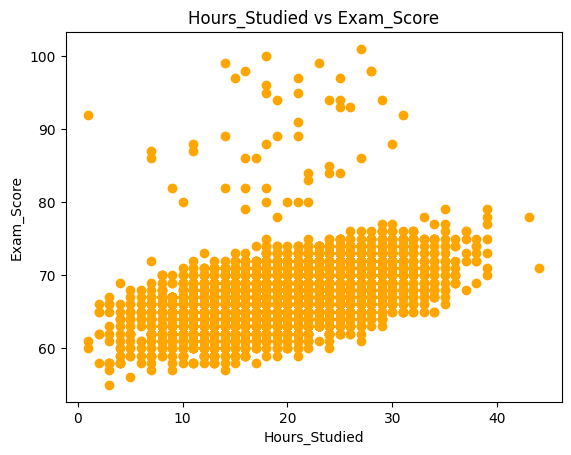

In [18]:
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='orange')
plt.xlabel('Hours_Studied')
plt.ylabel('Exam_Score')
plt.title('Hours_Studied vs Exam_Score')
plt.show()

In [19]:
df[['Hours_Studied', 'Exam_Score']].corr()

,Hours_Studied,Exam_Score
Hours_Studied,1.000000,0.445455
Exam_Score,0.445455,1.000000


умеренная зависимость

###Линейняя регресия

In [20]:
X = df[['Hours_Studied']]
y = df['Exam_Score']

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.289290628609581
Intercept: 61.456983609504064


Exam_Score = a * Hours_Studied + b

- a = 0.289290628609581
- b = 61.456983609504064

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


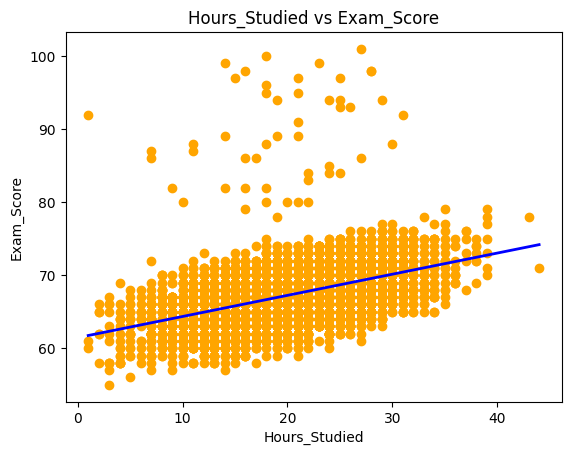

In [21]:
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='orange')

x_range = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 100)
y_pred = model.predict(x_range.reshape(-1, 1))

plt.plot(x_range, y_pred, color='blue', linewidth=2)

plt.xlabel('Hours_Studied')
plt.ylabel('Exam_Score')
plt.title('Hours_Studied vs Exam_Score')
plt.show()

###2. Есть ли точка насыщения?

In [22]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

LinearRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


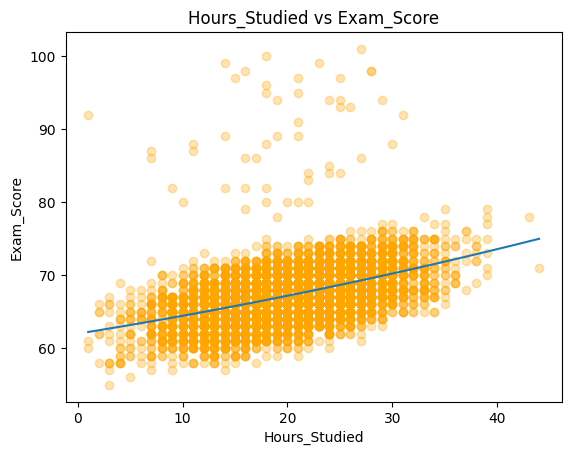

In [23]:
plt.scatter(df['Hours_Studied'], df['Exam_Score'], alpha=0.3, color='orange')

x_range = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 100)
x_poly = poly.transform(x_range.reshape(-1, 1))
y_poly_pred = model_poly.predict(x_poly)

plt.plot(x_range, y_poly_pred)
plt.xlabel('Hours_Studied')
plt.ylabel('Exam_Score')
plt.title('Hours_Studied vs Exam_Score')
plt.show()

Нет особой точки после которой эфективность падает

###3. Что важнее: Hours_Studied или Previous_Scores?

In [24]:
x = df[['Hours_Studied', 'Previous_Scores']]
y = df['Exam_Score']

model = LinearRegression()
model.fit(x, y)

print("Hours coef:", model.coef_[0])
print("Previous coef:", model.coef_[1])

Hours coef: 0.2866425828547015
Previous coef: 0.044339086035873436


In [25]:
scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)
model = LinearRegression()
model.fit(x_scaler, y)

print("Hours coef:", model.coef_[0])
print("Previous coef:", model.coef_[1])

Hours coef: 1.7170294785440718
Previous coef: 0.638424957456537


Часы проведенные за учебой решают больше чем предыдущие результаты

#Физиология

###1. Как Sleep_Hours влияет на Exam_Score?

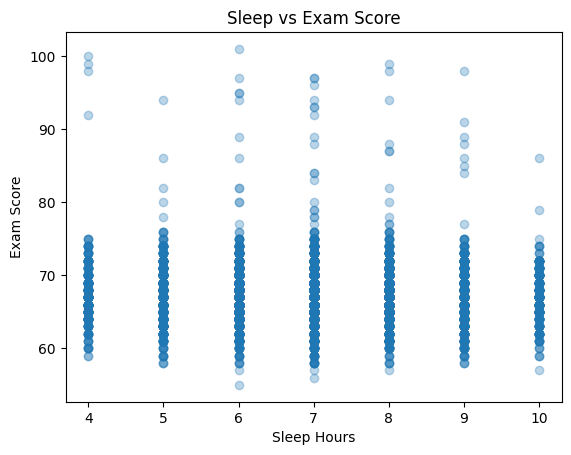

In [26]:
plt.scatter(df['Sleep_Hours'], df['Exam_Score'], alpha=0.3)
plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')
plt.title('Sleep vs Exam Score')
plt.show()

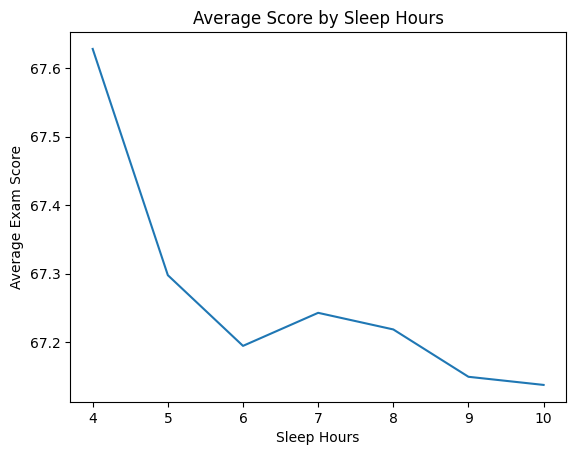

In [27]:
df.groupby('Sleep_Hours')['Exam_Score'].mean().plot(kind='line')
plt.xlabel('Sleep Hours')
plt.ylabel('Average Exam Score')
plt.title('Average Score by Sleep Hours')
plt.show()

гипотеза:
- мало спят → больше учатся (жёсткий режим)
- много спят → ниже дисциплина / мотивация

In [28]:
X = df[['Sleep_Hours', 'Motivation_Level', 'Hours_Studied']]
y = df['Exam_Score']

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [29]:
print(model.coef_)
print(model.intercept_)

[ 0.00000000e+00 -3.16725223e-01  7.37611308e-01  2.72487216e-01
  1.01910105e-02  5.33362097e-02  6.69561342e-04 -3.47234288e-02
 -2.34730284e-02  1.44223401e-03]
61.68702214255785


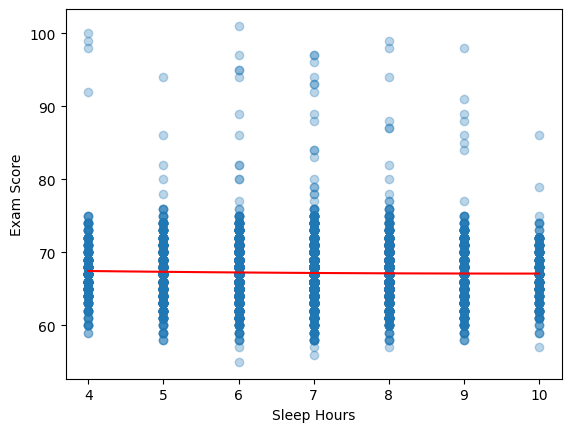

In [30]:
x_range = np.linspace(df['Sleep_Hours'].min(), df['Sleep_Hours'].max(), 100)

motivation_mean = df['Motivation_Level'].mean()
hours_mean = df['Hours_Studied'].mean()

X_range = pd.DataFrame({
    'Sleep_Hours': x_range,
    'Motivation_Level': motivation_mean,
    'Hours_Studied': hours_mean
})

X_poly_range = poly.transform(X_range)
y_pred = model.predict(X_poly_range)

plt.scatter(df['Sleep_Hours'], df['Exam_Score'], alpha=0.3)
plt.plot(x_range, y_pred, color='red')
plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')
plt.show()

Вопреки ожиданиям, продолжительность сна оказывает минимальное прямое влияние на результаты экзаменов.
 Разница в средних баллах при разных режимах сна незначительна, что говорит о том, что сам по себе сон не является значимым фактором.
 Однако дальнейший анализ показывает, что сон может выступать в качестве косвенного фактора, потенциально отражающего такие глубинные переменные, как учебные привычки или мотивация.

###2. Влияет ли Physical_Activity?

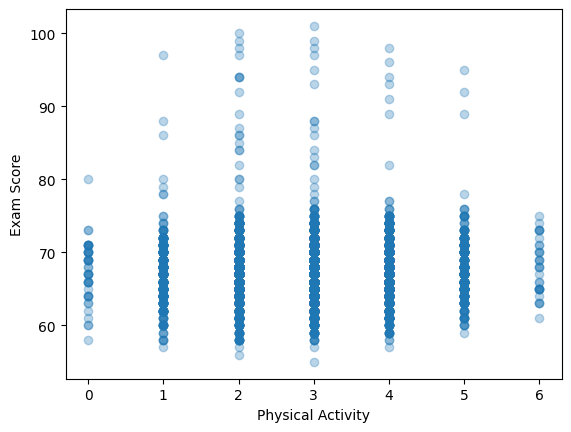

In [31]:
plt.scatter(df['Physical_Activity'], df['Exam_Score'], alpha=0.3)
plt.xlabel('Physical Activity')
plt.ylabel('Exam Score')
plt.show()

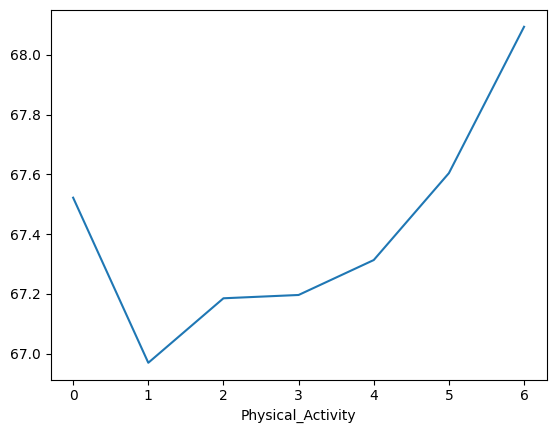

In [32]:
df.groupby('Physical_Activity')['Exam_Score'].mean().plot(kind='line')
plt.show()

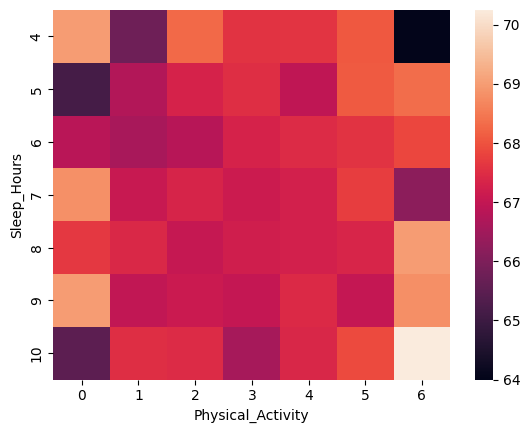

In [33]:
pivot = df.pivot_table(
    values='Exam_Score',
    index='Sleep_Hours',
    columns='Physical_Activity',
    aggfunc='mean'
)

sns.heatmap(pivot)
plt.show()

Анализ тепловой карты показывает, что продолжительность сна оказывает минимальное влияние на результаты экзаменов при любом уровне физической активности. Распределение цветов остается относительно стабильным при разной продолжительности сна, что подтверждает более ранние выводы о слабой корреляции.

 В отличие от продолжительности сна, физическая активность оказывает более заметное влияние. Более высокий уровень физической активности в целом связан с небольшим улучшением результатов экзаменов, что позволяет предположить, что активный образ жизни может положительно влиять на успеваемость.

 Однако не было выявлено какой-то одной оптимальной комбинации продолжительности сна и физической активности, что указывает на то, что этих факторов недостаточно для точного прогнозирования успеваемости учащихся.

# Мотивация и оценки за экзамены

###1. Как Motivation_Level влияет на Exam_Score?

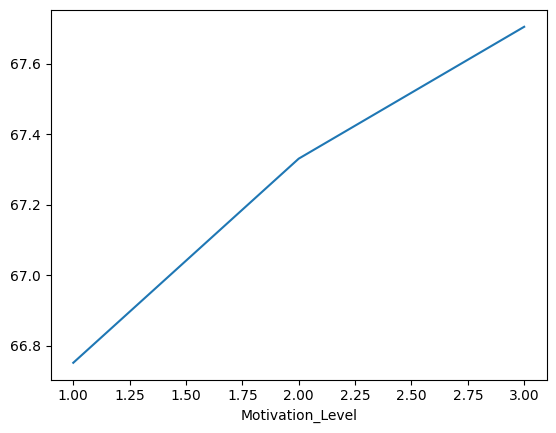

In [34]:
df.groupby('Motivation_Level')['Exam_Score'].mean().plot(kind='line')
plt.show()

#Социальные факторы

###Влияет ли Parental_Involvement?

<Axes: xlabel='Parental_Involvement', ylabel='Exam_Score'>

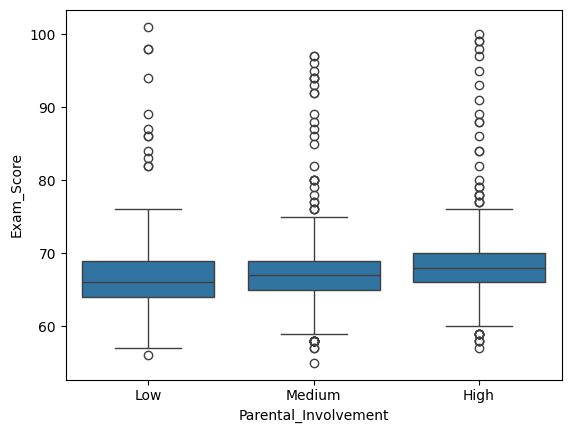

In [35]:
sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=df)

###Как Family_Income связан с Access_to_Resources и результатами?

In [36]:
pd.crosstab(df['Family_Income'], df['Access_to_Resources'], normalize= 'index')

Access_to_Resources,High,Low,Medium
Family_Income,,,
High,0.300236,0.187549,0.512214
Low,0.311003,0.199476,0.489521
Medium,0.286197,0.203301,0.510503


<Axes: xlabel='Family_Income'>

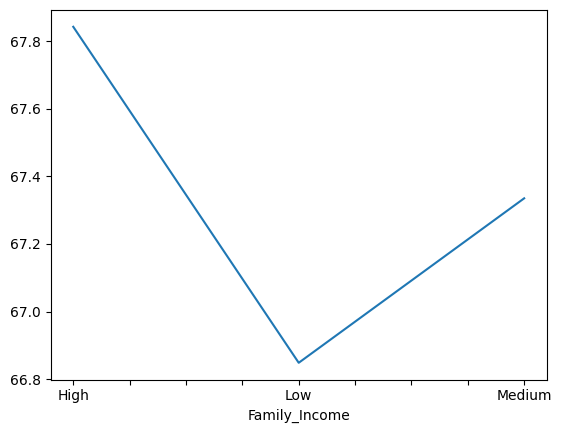

In [37]:
df.groupby('Family_Income')['Exam_Score'].mean().plot(kind='line')

<Axes: xlabel='Access_to_Resources'>

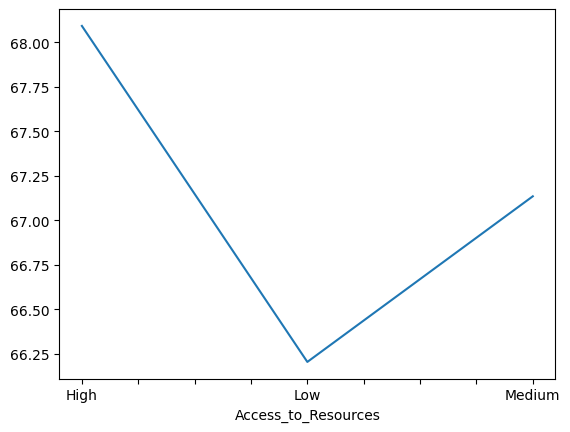

In [38]:
df.groupby('Access_to_Resources')['Exam_Score'].mean().plot(kind='line')

###Влияет ли Parental_Education_Level?

<Axes: xlabel='Parental_Education_Level'>

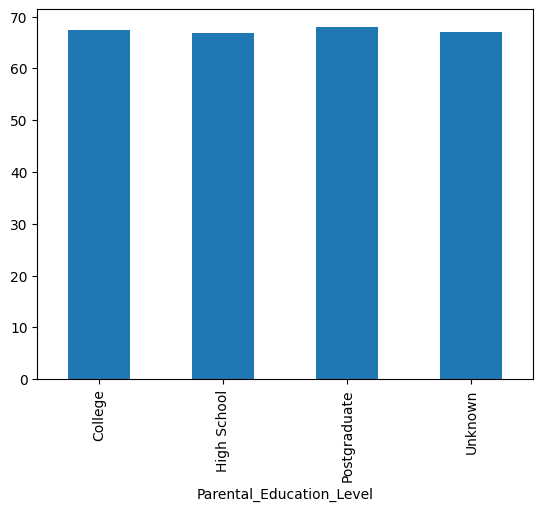

In [39]:
df.groupby('Parental_Education_Level')['Exam_Score'].mean().plot(kind='bar')

###Влияет ли Teacher_Quality?

<Axes: xlabel='Teacher_Quality', ylabel='Exam_Score'>

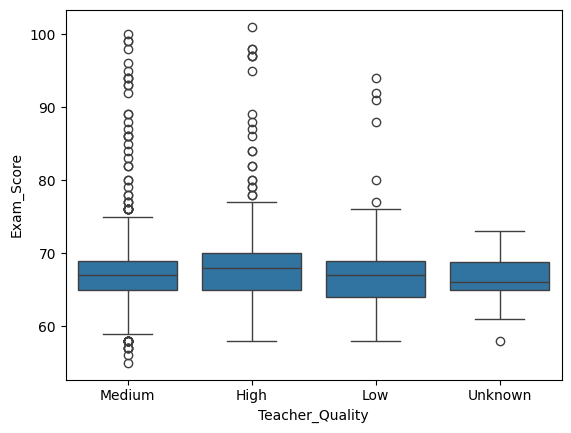

In [40]:
sns.boxplot(x='Teacher_Quality', y='Exam_Score', data=df)

###Разница School_Type

<Axes: xlabel='School_Type', ylabel='Exam_Score'>

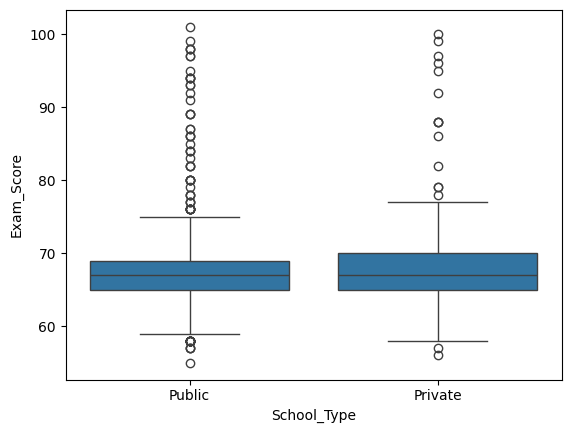

In [41]:
sns.boxplot(x='School_Type', y='Exam_Score', data=df)

###Peer_Influence

<Axes: xlabel='Peer_Influence'>

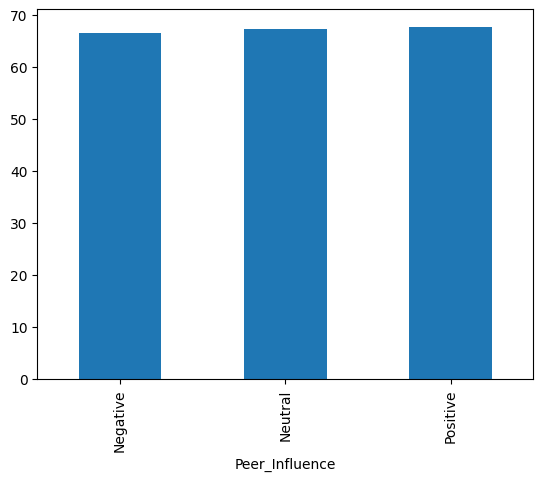

In [42]:
df.groupby('Peer_Influence')['Exam_Score'].mean().plot(kind='bar')

###Distance_from_Home

<Axes: xlabel='Distance_from_Home'>

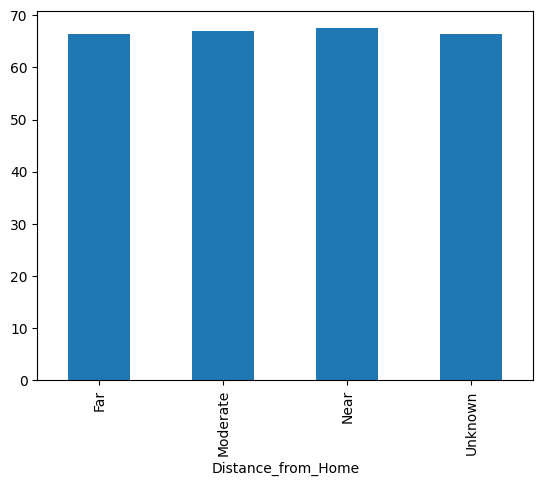

In [43]:
df.groupby('Distance_from_Home')['Exam_Score'].mean().plot(kind='bar')

#Доступ к ресурсам

###Влияет ли Internet_Access?

<Axes: xlabel='Internet_Access', ylabel='Exam_Score'>

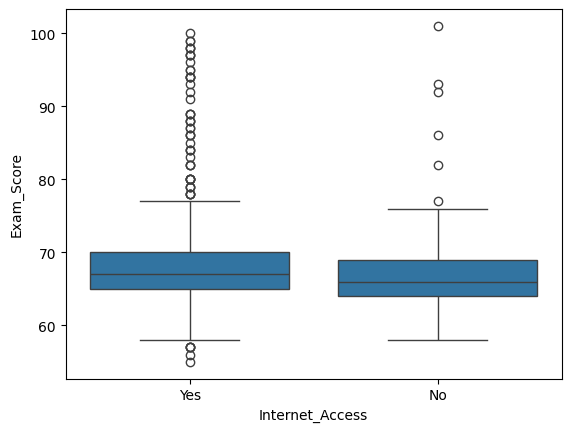

In [44]:
sns.boxplot(x='Internet_Access', y='Exam_Score', data=df)

###Помогают ли Tutoring_Sessions?

<Axes: xlabel='Tutoring_Sessions'>

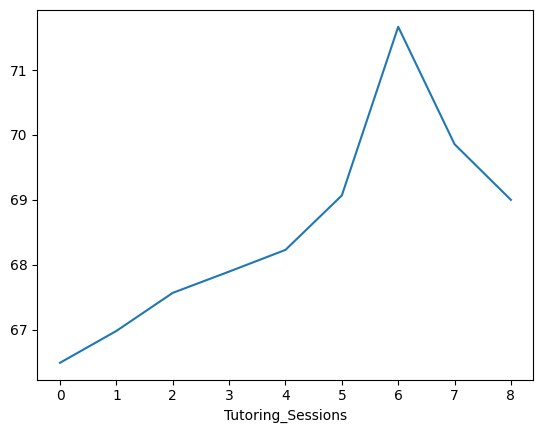

In [45]:
df.groupby('Tutoring_Sessions')['Exam_Score'].mean().plot(kind='line')

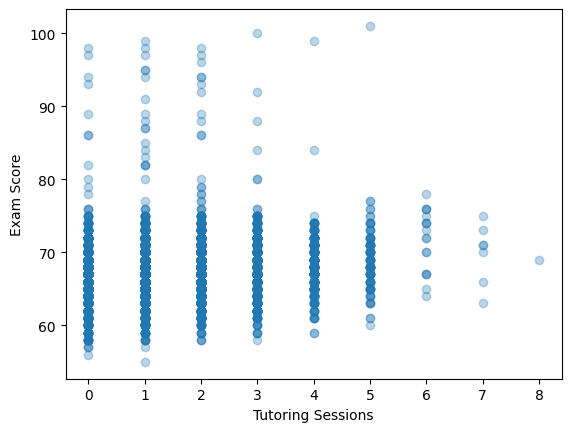

In [46]:
plt.scatter(df['Tutoring_Sessions'], df['Exam_Score'], alpha=0.3)
plt.xlabel('Tutoring Sessions')
plt.ylabel('Exam Score')
plt.show()

###Что важнее: интернет или репетитор?

In [47]:
df['Internet_num'] = df['Internet_Access'].map({'No': 0, 'Yes': 1})

In [48]:
X = df[['Internet_num', 'Tutoring_Sessions']]
y = df['Exam_Score']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

print("Internet importance:", model.coef_[0])
print("Tutoring importance:", model.coef_[1])

Internet importance: 0.20639931745202167
Tutoring importance: 0.6109868617737676


Учеба с репетитарома дает больше эфекта чем самообучение

####Работают ли они вместе?

<Axes: xlabel='Internet_Access'>

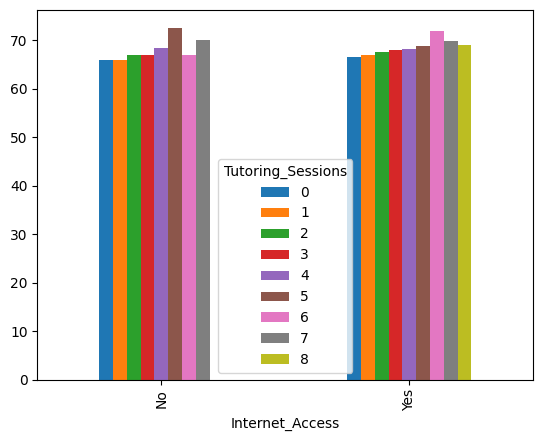

In [49]:
pivot = df.pivot_table(
    values='Exam_Score',
    index='Internet_Access',
    columns='Tutoring_Sessions',
    aggfunc='mean'
)

pivot.plot(kind='bar')

In [50]:
df['Tutoring_Group'] = df['Tutoring_Sessions'].apply(lambda x: 'Low' if x <= 2 else 'High')

In [51]:
df.groupby(['Internet_Access', 'Tutoring_Group'])['Exam_Score'].mean()

Internet_Access  Tutoring_Group
No               High              67.614679
                 Low               66.233333
Yes              High              68.184097
                 Low               67.084629
Name: Exam_Score, dtype: float64

###Может ли Attendance компенсировать низкую мотивацию?

In [52]:
def attendance_group(x):
    if x < 70:
        return 'Low'
    elif x < 85:
        return 'Medium'
    else:
        return 'High'
df['Attendance_Group'] = df['Attendance'].apply(attendance_group)

<Axes: xlabel='Attendance_Group'>

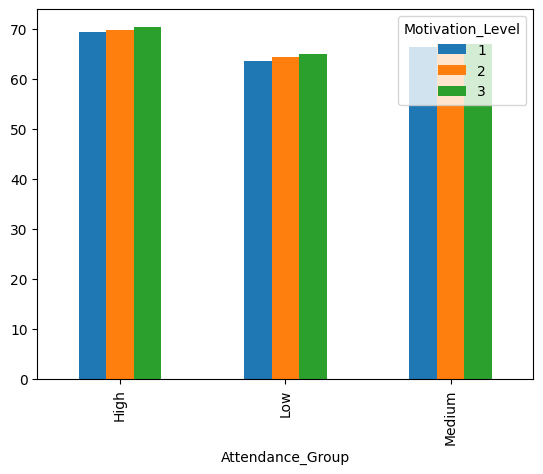

In [53]:
pivot = df.pivot_table(
    values='Exam_Score',
    index='Attendance_Group',
    columns='Motivation_Level',
    aggfunc='mean'
)

pivot.plot(kind='bar')

Посещаемость выступает в качестве стабилизирующего фактора, частично компенсирующего низкую мотивацию.
 Учащиеся с высокой посещаемостью, но низкой мотивацией, часто показывают лучшие результаты, чем те, у кого высокая мотивация, но низкая посещаемость, что подчеркивает важность постоянства в отличие от намерений.

#Аномалии: «мало учатся, но хорошо сдают»

In [54]:
low_study = df['Hours_Studied'] < df['Hours_Studied'].quantile(0.25)
high_score = df['Exam_Score'] > df['Exam_Score'].quantile(0.75)
anomalies = df[low_study & high_score]

In [55]:
anomalies.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Physical_Activity,Exam_Score,Teacher_Quality_num,Parental_Education_num,Distance_num,Internet_num
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,12.758242,92.549451,6.747253,80.703297,2.153846,2.120879,2.945055,72.714286,2.285714,2.120879,2.703297,0.934066
std,2.487036,8.873511,1.371077,12.936163,0.631103,1.331959,0.958733,6.114256,0.582823,0.841099,0.605429,0.249542
min,1.000000,61.000000,4.000000,50.000000,1.000000,0.000000,0.000000,70.000000,1.000000,0.000000,0.000000,0.000000
25%,12.000000,90.500000,6.000000,73.000000,2.000000,1.000000,2.000000,70.000000,2.000000,1.000000,3.000000,1.000000
50%,14.000000,96.000000,7.000000,83.000000,2.000000,2.000000,3.000000,71.000000,2.000000,2.000000,3.000000,1.000000
75%,15.000000,98.000000,8.000000,90.500000,3.000000,3.000000,4.000000,71.000000,3.000000,3.000000,3.000000,1.000000
max,15.000000,100.000000,10.000000,100.000000,3.000000,7.000000,5.000000,99.000000,3.000000,3.000000,3.000000,1.000000


#Кто успешнее: дисциплина или талант?

In [56]:
def attendance_type(x):
    return 'High Attendance' if x >= 85 else 'Low Attendance'
def talent_type(x):
    return 'High Talent' if x >= df['Previous_Scores'].median() else 'Low Talent'

df['Attendance_Type'] = df['Attendance'].apply(attendance_type)
df['Talent_Type'] = df['Previous_Scores'].apply(talent_type)

In [57]:
df.groupby(['Attendance_Type', 'Talent_Type'])['Exam_Score'].mean()

Attendance_Type  Talent_Type
High Attendance  High Talent    70.398394
                 Low Talent     69.002370
Low Attendance   High Talent    66.319510
                 Low Talent     65.092705
Name: Exam_Score, dtype: float64

<Axes: xlabel='Attendance_Type', ylabel='Exam_Score'>

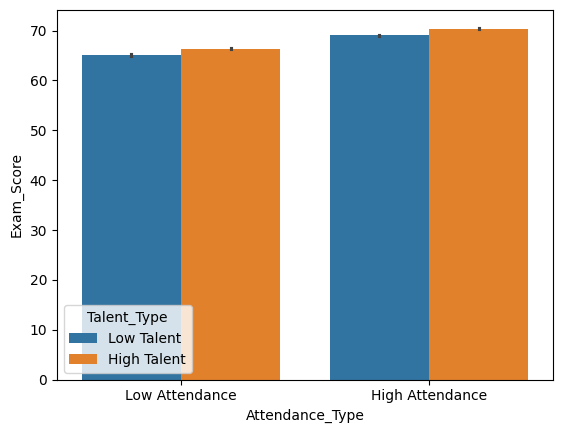

In [58]:
sns.barplot(
    x='Attendance_Type',
    y='Exam_Score',
    hue='Talent_Type',
    data=df
)

#Сегментация

In [59]:
def performance_group(score):
    if score < df['Exam_Score'].quantile(0.33):
        return 'Low'
    elif score < df['Exam_Score'].quantile(0.66):
        return 'Medium'
    else:
        return 'High'
df['Performance_Group'] = df['Exam_Score'].apply(performance_group)

In [60]:
df['Performance_Group'].value_counts()

,count
Performance_Group,
High,2249
Medium,2227
Low,2131


In [61]:
df.groupby('Performance_Group').mean(numeric_only=True)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Physical_Activity,Exam_Score,Teacher_Quality_num,Parental_Education_num,Distance_num,Internet_num
Performance_Group,,,,,,,,,,,,
High,23.096932,88.923966,7.020454,78.169853,1.966207,1.711427,2.983548,71.161850,2.238328,1.780791,2.550467,0.940863
Low,16.727827,70.770061,7.038010,71.911779,1.822618,1.249648,2.935711,63.334585,2.121070,1.569686,2.382919,0.905678
Medium,19.930400,79.753031,7.029187,74.963179,1.926358,1.507409,2.982039,67.003592,2.152672,1.691064,2.466098,0.925909


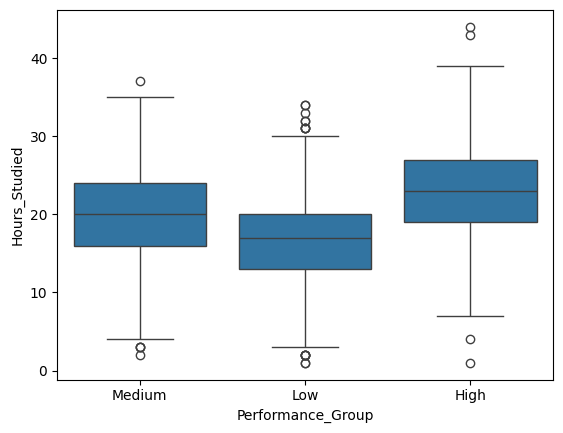

In [62]:
sns.boxplot(x='Performance_Group', y='Hours_Studied', data=df)
plt.show()

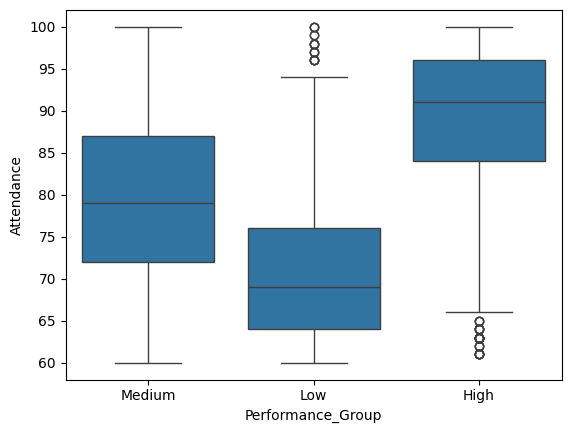

In [63]:
sns.boxplot(x='Performance_Group', y='Attendance', data=df)
plt.show()

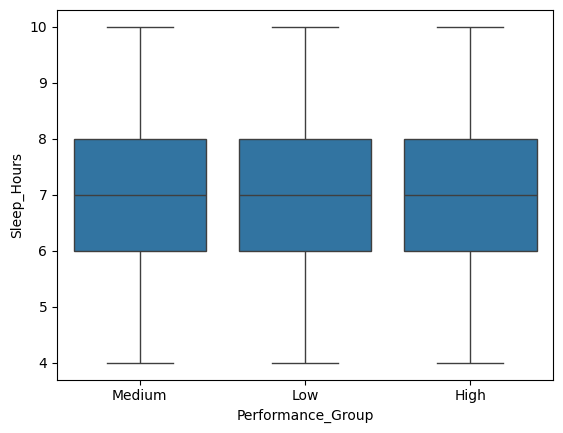

In [64]:
sns.boxplot(x='Performance_Group', y='Sleep_Hours', data=df)
plt.show()

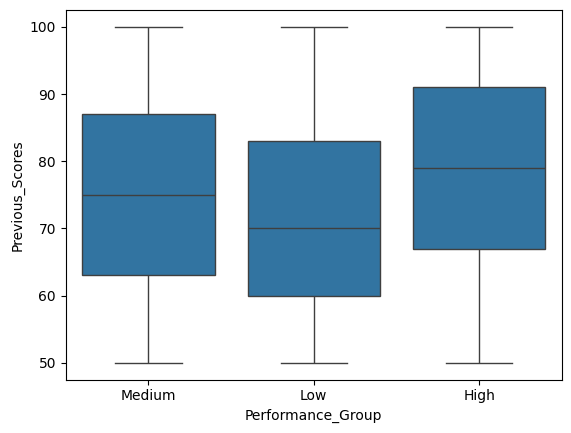

In [65]:
sns.boxplot(x='Performance_Group', y='Previous_Scores', data=df)
plt.show()

###Какие факторы «типичны» для успешных?

In [66]:
pd.crosstab(df['Performance_Group'], df['Parental_Involvement'], normalize='index')

Parental_Involvement,High,Low,Medium
Performance_Group,,,
High,0.364162,0.148955,0.486883
Low,0.216330,0.264195,0.519474
Medium,0.281994,0.197126,0.520880


In [67]:
pd.crosstab(df['Performance_Group'], df['Teacher_Quality'], normalize='index')

Teacher_Quality,High,Low,Medium,Unknown
Performance_Group,,,,
High,0.340596,0.084482,0.566029,0.008893
Low,0.262787,0.116377,0.608165,0.012670
Medium,0.278850,0.098339,0.608891,0.013920


In [68]:
pd.crosstab(df['Performance_Group'], df['School_Type'], normalize='index')

School_Type,Private,Public
Performance_Group,,
High,0.306358,0.693642
Low,0.295636,0.704364
Medium,0.309834,0.690166


In [69]:
pd.crosstab(df['Performance_Group'], df['Internet_Access'], normalize='index')

Internet_Access,No,Yes
Performance_Group,,
High,0.059137,0.940863
Low,0.094322,0.905678
Medium,0.074091,0.925909


In [70]:
pd.crosstab(df['Performance_Group'], df['Peer_Influence'], normalize='index')

Peer_Influence,Negative,Neutral,Positive
Performance_Group,,,
High,0.164073,0.385505,0.450422
Low,0.254341,0.405443,0.340216
Medium,0.209250,0.386619,0.404131


<Axes: >

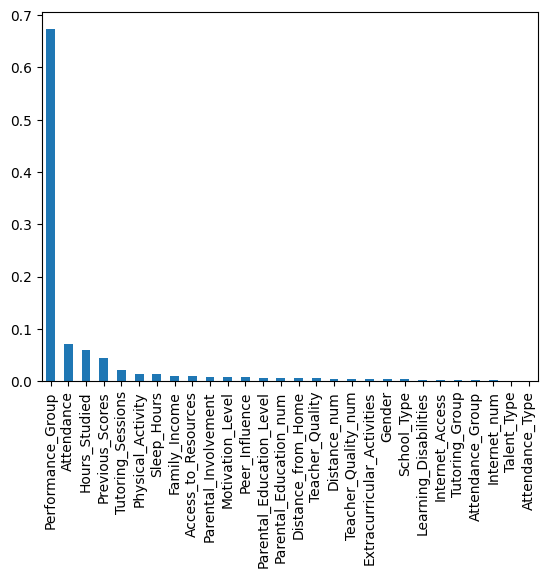

In [71]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop(columns=['Exam_Score'])
y = df_encoded['Exam_Score']

model = RandomForestRegressor()
model.fit(X, y)

import pandas as pd
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')